In [2]:
# Gerekli kütüphanelerin kurulumu
!pip install catboost scikit-learn matplotlib seaborn pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [3]:
# 1. VERİ YÜKLEME VE ÖN İŞLEME
print("Veri yükleniyor...")
try:
    df = pd.read_csv('/content/drive/MyDrive/diabet_erken_teshis/diabetic_data_processed.csv')
except FileNotFoundError:
    raise FileNotFoundError("Lütfen 'diabetic_data_processed.csv' dosyasını Colab'e yükleyin.")

# Hedef ve Öznitelik Ayrımı
X = df.drop('target', axis=1)
y = df['target']

# Eğitim ve Test Ayrımı (%80 Eğitim, %20 Test)
# Stratify=y ile dengesiz dağılımı koruyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ölçeklendirme (Modellerin daha hızlı yakınsaması için)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim Seti: {X_train.shape}, Test Seti: {X_test.shape}")

# Dengesizlik Oranını Hesaplama (CatBoost için ağırlık)
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

Veri yükleniyor...
Eğitim Seti: (81410, 132), Test Seti: (20353, 132)


In [4]:
# 2. HİPERPARAMETRE OPTİMİZASYONU VE EĞİTİM

# Sonuçları tutacak sözlük
best_models = {}
results_data = {}

In [5]:
# --- MODEL 1: CatBoost Classifier ---
print("\n1. CatBoost Modeli için En İyi Parametreler Aranıyor (Grid Search)...")

# Aranacak parametre uzayı
cat_params = {
    'depth': [4, 6],              # Ağaç derinliği
    'learning_rate': [0.05, 0.1], # Öğrenme hızı
    'iterations': [200, 500]      # Ağaç sayısı
}

cat = CatBoostClassifier(
    loss_function='Logloss',
    scale_pos_weight=scale_pos_weight, # Dengesiz veri ayarı
    verbose=0,
    random_state=42
)

# F1 skoru öncelikli optimizasyon (Sağlık verisi olduğu için)
cat_grid = GridSearchCV(cat, cat_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
cat_grid.fit(X_train_scaled, y_train)

best_models['CatBoost'] = cat_grid.best_estimator_
print(f"   -> En iyi CatBoost Parametreleri: {cat_grid.best_params_}")


1. CatBoost Modeli için En İyi Parametreler Aranıyor (Grid Search)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
   -> En iyi CatBoost Parametreleri: {'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


In [6]:
# MODEL 2: Extra Trees Classifier
print("\n2. Extra Trees Modeli için En İyi Parametreler Aranıyor (Grid Search)...")

# Aranacak parametre uzayı
et_params = {
    'n_estimators': [100, 200],       # Ağaç sayısı
    'max_depth': [None, 20],          # Maksimum derinlik
    'min_samples_split': [2, 5],      # Bölünme için min örnek
    'class_weight': ['balanced']      # Dengesiz veri ayarı
}

et = ExtraTreesClassifier(random_state=42)

# F1 skoru öncelikli optimizasyon
et_grid = GridSearchCV(et, et_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
et_grid.fit(X_train_scaled, y_train)

best_models['Extra Trees'] = et_grid.best_estimator_
print(f"   -> En iyi Extra Trees Parametreleri: {et_grid.best_params_}")


2. Extra Trees Modeli için En İyi Parametreler Aranıyor (Grid Search)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
   -> En iyi Extra Trees Parametreleri: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [7]:
# 3. TAHMİN VE METRİKLERİN HESAPLANMASI
metrics_list = []

for name, model in best_models.items():
    # Tahminler
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrikler
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)      # Duyarlılık (Sensitivity) - KRİTİK
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Verileri sakla
    results_data[name] = {'pred': y_pred, 'prob': y_prob}

    metrics_list.append({
        'Model': name,
        'Accuracy': acc,
        'Recall (Sensitivity)': rec,
        'Precision': prec,
        'F1 Score': f1,
        'AUC': auc
    })

metrics_df = pd.DataFrame(metrics_list)


In [8]:
# 4. GÖRSELLEŞTİRME

# A) Karşılaştırma Tablosu
print("\n" + "="*20 + " MODEL PERFORMANS TABLOSU " + "="*20)
display_metrics = metrics_df.style.background_gradient(cmap='YlOrRd', subset=['Recall (Sensitivity)', 'F1 Score'])
from IPython.display import display
display(display_metrics)


==================== MODEL PERFORMANS TABLOSU ====================


,Model,Accuracy,Recall (Sensitivity),Precision,F1 Score,AUC
0,CatBoost,0.680195,0.579480,0.191557,0.287933,0.691366
1,Extra Trees,0.762394,0.394100,0.205511,0.270148,0.649119


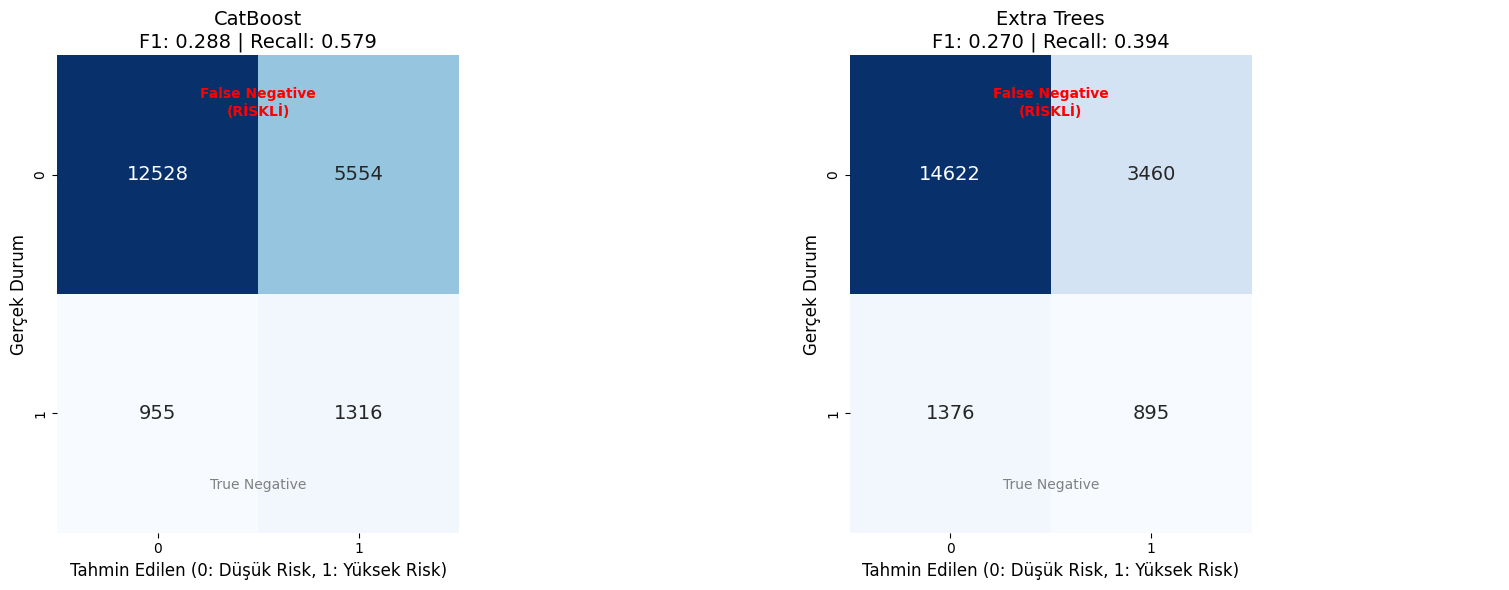

In [9]:
# B) Confusion Matrix (Yan Yana)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, res) in enumerate(results_data.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 14})

    # Başlık ve Etiketler
    axes[i].set_title(f'{name}\nF1: {f1_score(y_test, res["pred"]):.3f} | Recall: {recall_score(y_test, res["pred"]):.3f}', fontsize=14)
    axes[i].set_xlabel('Tahmin Edilen (0: Düşük Risk, 1: Yüksek Risk)', fontsize=12)
    axes[i].set_ylabel('Gerçek Durum', fontsize=12)

    # Matris içindeki etiketler
    axes[i].text(0.5, 0.1, 'True Negative', ha='center', va='center', color='gray', transform=axes[i].transAxes)
    axes[i].text(1.5, 0.1, 'False Positive', ha='center', va='center', color='white', transform=axes[i].transAxes)
    axes[i].text(0.5, 0.9, 'False Negative\n(RİSKLİ)', ha='center', va='center', color='red', transform=axes[i].transAxes, fontweight='bold')
    axes[i].text(1.5, 0.9, 'True Positive\n(Yakalanan)', ha='center', va='center', color='white', transform=axes[i].transAxes)

plt.tight_layout()
plt.show()


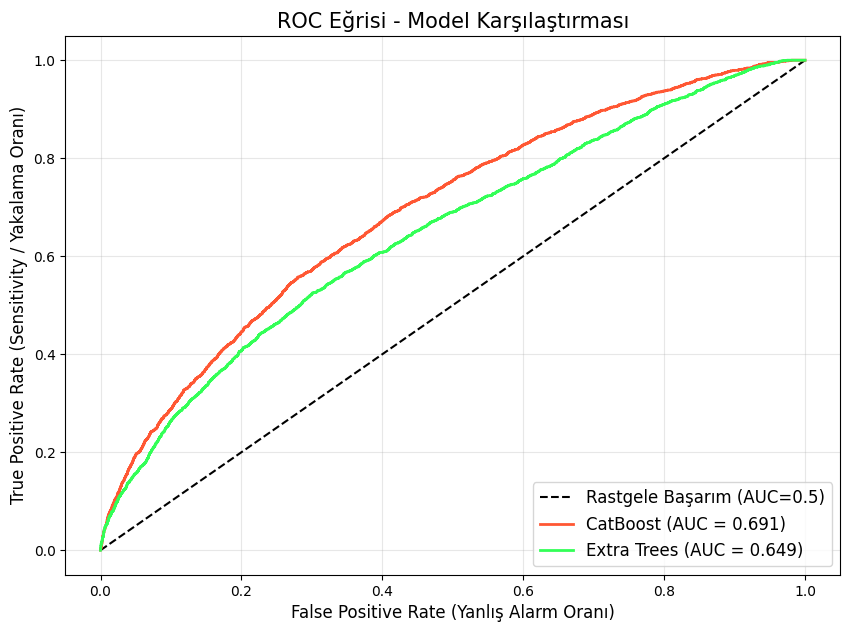

In [10]:
# C) ROC Eğrisi (Karşılaştırmalı)
plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Başarım (AUC=0.5)')

colors = ['#FF5733', '#33FF57'] # Renkler
for i, (name, res) in enumerate(results_data.items()):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    auc_score = metrics_df[metrics_df['Model'] == name]['AUC'].values[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2, color=colors[i])

plt.xlabel('False Positive Rate (Yanlış Alarm Oranı)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Yakalama Oranı)', fontsize=12)
plt.title('ROC Eğrisi - Model Karşılaştırması', fontsize=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
# 5. YORUM VE SONRAKİ ADIM
best_model_name = metrics_df.sort_values(by='F1 Score', ascending=False).iloc[0]['Model']
print(f"\n Sonuç: F1 Skoruna ve Duyarlılığa göre bu oturumun kazananı: **{best_model_name}**")
print("Not: 'False Negative' (Sol Alt Köşe) sayısı ne kadar düşükse, model o kadar az hasta kaçırıyor demektir.")


 Sonuç: F1 Skoruna ve Duyarlılığa göre bu oturumun kazananı: **CatBoost**
Not: 'False Negative' (Sol Alt Köşe) sayısı ne kadar düşükse, model o kadar az hasta kaçırıyor demektir.


In [14]:
import joblib
from google.colab import files

# 1. EN İYİ MODELİ BELİRLEME (OTOMATİK)
# ---------------------------------------------------------
# F1 skoruna göre sırala ve en iyisini seç
best_row = metrics_df.sort_values(by='F1 Score', ascending=False).iloc[0]

# Modelin ismini al (Örn: "CatBoost" veya "Extra Trees")
winning_model_name = best_row['Model']
best_score = best_row['F1 Score']

# Sözlükten o isme ait eğitilmiş modeli çek
final_model_to_save = best_models[winning_model_name]

print(f" KAZANAN MODEL: {winning_model_name}")
print(f" F1 Skoru: {best_score:.4f}")

# 2. DİNAMİK DOSYA İSMİ OLUŞTURMA
# ---------------------------------------------------------
# Boşluk varsa alt çizgi yap (Örn: "Extra Trees" -> "Extra_Trees")
clean_name = winning_model_name.replace(" ", "_")

# Dosya ismini modelin kendi adıyla oluştur
model_filename = f"{clean_name}_trained_model.pkl"
scaler_filename = "scaler.pkl"

# 3. KAYDETME VE İNDİRME
# ---------------------------------------------------------
print(f"\n Kaydediliyor: {model_filename} ...")
joblib.dump(final_model_to_save, model_filename)

print(f" Kaydediliyor: {scaler_filename} ...")
joblib.dump(scaler, scaler_filename)

# Bilgisayara İndir (Google Colab için)
print("\n⬇ Dosyalar indiriliyor...")
files.download(model_filename)
files.download(scaler_filename)

 KAZANAN MODEL: CatBoost
 F1 Skoru: 0.2879

 Kaydediliyor: CatBoost_trained_model.pkl ...
 Kaydediliyor: scaler.pkl ...

⬇ Dosyalar indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>